# Review LLM Judgments

Browse and filter the LLM-judged survey-vote matches.
Each pair has been scored by Mistral (via Ollama) with a relevance score, explanation, and go/no-go verdict.


In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
JUDGED_CSV = DATA_DIR / "matches" / "survey_vote_matches_judged.csv"

df = pd.read_csv(JUDGED_CSV)
print(f"Total judged pairs: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()


Total judged pairs: 8
Columns: ['question_id', 'question_text', 'file_name', 'vote_id', 'vote_summary', 'similarity_score', 'llm_score', 'llm_explanation', 'llm_go']


,question_id,question_text,file_name,vote_id,vote_summary,similarity_score,llm_score,llm_explanation,llm_go
0,QB7_2,QB7.2. The European Year of Skills is taking p...,Lien_vers_SP546_volume_B.xlsx,153918,The European Parliament adopted by 524 votes t...,0.789827,9,The vote is about declaring a European Year of...,True
1,QB7_1,QB7.1. The European Year of Skills is taking p...,Lien_vers_SP546_volume_B.xlsx,153918,The European Parliament adopted by 524 votes t...,0.777720,9,The vote is about declaring a European Year of...,True
2,Q7_1,"Q7_1 For each of the following initiatives, pl...",Lien_vers_fl_539_volume_B.xlsx,126261,The European Parliament adopted by 550 votes t...,0.746313,9,The vote is about a strategy on adaptation to ...,True
3,Q1_1,Q1_1 Imagine a major crisis affecting [YOUR CO...,Lien_vers_fl_546_volume_B.xlsx,157227,Evaluation of the effectiveness of EU and nati...,0.744503,9,Both question and vote are about EU's response...,True
4,Q3_6,Q3_6 To what extent do you agree or disagree w...,Lien_vers_l’évolution_démographique_en_europe_...,134947,The European Parliament adopted by 479 votes t...,0.742232,9,The vote discusses demographic trends in the E...,True


## Summary statistics


In [5]:
# Filter out failed parses
valid = df[df["llm_score"] > 0].copy()
print(f"Valid judgments: {len(valid)} / {len(df)}")
print(f"Parse errors: {(df['llm_score'] == -1).sum()}")
print()

# Go / No-Go breakdown
n_go = valid["llm_go"].sum()
n_nogo = len(valid) - n_go
print(f"Go:    {n_go}  ({100 * n_go / len(valid):.1f}%)")
print(f"No-Go: {n_nogo}  ({100 * n_nogo / len(valid):.1f}%)")
print()

# Score stats
print(f"Score distribution:")
print(valid["llm_score"].describe().round(2))


Valid judgments: 8 / 8
Parse errors: 0

Go:    8  (100.0%)
No-Go: 0  (0.0%)

Score distribution:
count    8.0
mean     9.0
std      0.0
min      9.0
25%      9.0
50%      9.0
75%      9.0
max      9.0
Name: llm_score, dtype: float64


## Score distribution


/var/folders/j3/mm5hxwf11p18skbfc4mkjsgr0000gn/T/ipykernel_3449/2263397468.py:25: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/ugo/Documents/MH2D_projets/michlougo/eu_survey_correlation/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


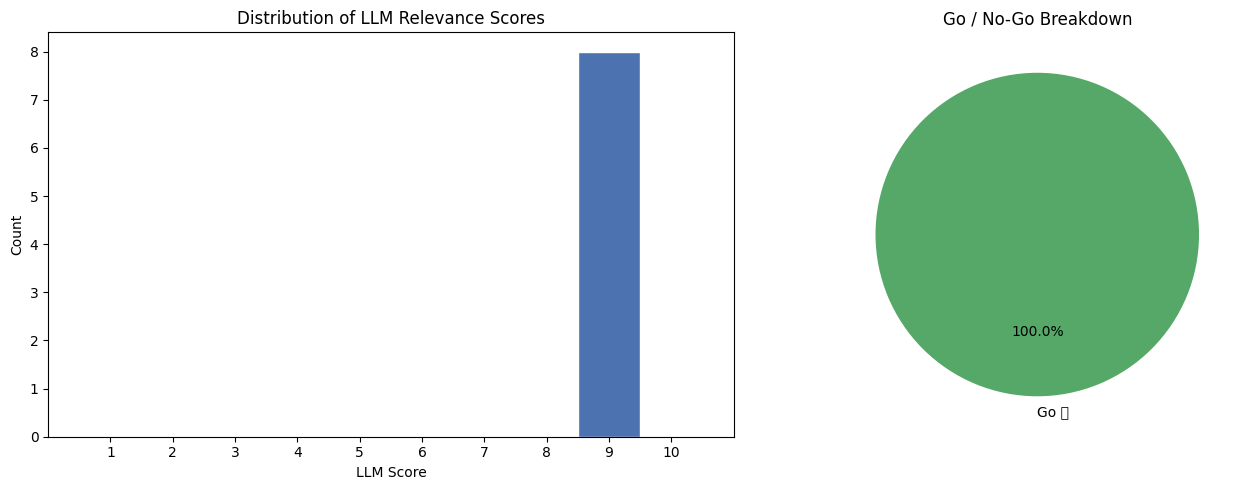

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of scores
axes[0].hist(
    valid["llm_score"],
    bins=range(1, 12),
    edgecolor="white",
    color="#4c72b0",
    align="left",
)
axes[0].set_xlabel("LLM Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of LLM Relevance Scores")
axes[0].set_xticks(range(1, 11))

# Go / No-Go pie chart
go_counts = valid["llm_go"].value_counts()
labels = ["Go ✅" if k else "No-Go ❌" for k in go_counts.index]
colors = ["#55a868" if k else "#c44e52" for k in go_counts.index]
axes[1].pie(
    go_counts.values, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90
)
axes[1].set_title("Go / No-Go Breakdown")

plt.tight_layout()
plt.show()


## Top "Go" matches (highest scored)


In [7]:
go_df = valid[valid["llm_go"] == True].sort_values("llm_score", ascending=False)

display_cols = [
    "question_text",
    "vote_summary",
    "similarity_score",
    "llm_score",
    "llm_explanation",
    "llm_go",
]

print(f"✅ {len(go_df)} 'Go' matches")
go_df[display_cols].head(20).style.set_properties(
    subset=["question_text", "vote_summary"],
    **{"max-width": "400px", "white-space": "normal"},
)


✅ 8 'Go' matches


,question_text,vote_summary,similarity_score,llm_score,llm_explanation,llm_go
0,"QB7.2. The European Year of Skills is taking place between May 2023 and May 2024. It aims to raise awareness about the need for people to get the right skills for quality jobs and thereby also aims to support companies in addressing skill shortages in Europe. For each of the following statements, tell me if it applies to you? :-You are currently engaging in training to improve your skills","The European Parliament adopted by 524 votes to 33, with 24 abstentions, a legislative resolution on the proposal for a decision of the European Parliament and of the Council on a European Year of Skills 2023. The European Parliament's position adopted at first reading under the ordinary legislative procedure amends the Commission's proposal as follows: As proposed by Members, the period from 9 May 2023 to 8 May 2024 will be declared the ‘European Year of Skills’ . The overall objective of the E",0.789827,9,"The vote is about declaring a European Year of Skills, which aligns with the survey question's focus on skills and training.",True
1,"QB7.1. The European Year of Skills is taking place between May 2023 and May 2024. It aims to raise awareness about the need for people to get the right skills for quality jobs and thereby also aims to support companies in addressing skill shortages in Europe. For each of the following statements, tell me if it applies to you? :-You are currently actively looking for information concerning training to improve your skills?","The European Parliament adopted by 524 votes to 33, with 24 abstentions, a legislative resolution on the proposal for a decision of the European Parliament and of the Council on a European Year of Skills 2023. The European Parliament's position adopted at first reading under the ordinary legislative procedure amends the Commission's proposal as follows: As proposed by Members, the period from 9 May 2023 to 8 May 2024 will be declared the ‘European Year of Skills’ . The overall objective of the E",0.777720,9,"The vote is about declaring a European Year of Skills, which aligns with the survey question's focus on skills and training.",True
2,"Q7_1 For each of the following initiatives, please tell me how effective or not you think they will be in helping to tackle the challenges facing the EU. The EU’s plan aiming to tackle climate change and transform the EU into a competitive, green, climate neutral economy by 2050., i.e. the European Green Deal","The European Parliament adopted by 550 votes to 80, with 59 abstentions, a resolution on the EU strategy on adaptation to climate change. According to estimates by the European Environment Agency (EEA), extreme weather and climate events accounted for EUR 426 billion in monetary terms in the EU-28 over the period 1980-2017. Damage costs from climate change are expected to be high, even if the Paris Agreement is implemented. Only an ambitious global mitigation policy can significantly reduce clim",0.746313,9,"The vote is about a strategy on adaptation to climate change within the EU, which aligns closely with the survey question's focus on tackling climate change in the EU.",True
3,"Q1_1 Imagine a major crisis affecting [YOUR COUNTRY] and surrounding countries. How effective or not do you think the EU’s response would be in each of the following situations? Managing health emergencies (e.g. COVID-19 pandemic, epidemics)","Evaluation of the effectiveness of EU and national measures Recommendations to improve EU crisis management and preparedness for future health emergencies Increase parliamentary oversight of measures, coordination, solidarity",0.744503,9,Both question and vote are about EU's response to health emergencies.,True
4,"Q3_6 To what extent do you agree or disagree with the following statements about the current demographic trends in the EU, such as population ageing and a shrinking workforce? The current demographic trend…affect my prospects and future p

## Worst-scored matches (sanity check)

These should be clearly unrelated pairs. If they look related, the LLM might need prompt tuning.


In [ ]:
worst = valid.sort_values("llm_score", ascending=True)

print(f"❌ Lowest scored matches:")
worst[display_cols].head(20).style.set_properties(
    subset=["question_text", "vote_summary"],
    **{"max-width": "400px", "white-space": "normal"},
)


## Similarity score vs LLM score

Compare the embedding cosine similarity with the LLM's qualitative judgment.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    valid["similarity_score"],
    valid["llm_score"],
    c=valid["llm_go"].map({True: "#55a868", False: "#c44e52"}),
    alpha=0.4,
    s=15,
)
ax.set_xlabel("Cosine Similarity (embedding)")
ax.set_ylabel("LLM Score (1-10)")
ax.set_title("Embedding Similarity vs. LLM Relevance Score")
ax.axhline(y=7, color="gray", linestyle="--", alpha=0.5, label="Go threshold (7)")
ax.legend(["Go threshold"], loc="lower right")
plt.tight_layout()
plt.show()


## Browse individual pairs

Use this section to inspect specific pairs interactively.


In [ ]:
def show_pair(idx: int):
    """Display a single match pair with its judgment."""
    row = df.iloc[idx]
    print(f"{'=' * 80}")
    print(f"Pair #{idx}")
    print(f"{'=' * 80}")
    print(f"\n📋 SURVEY QUESTION ({row.get('question_id', 'N/A')}):")
    print(f"   {row['question_text'][:500]}")
    print(f"\n🗳️  VOTE ({row.get('vote_id', 'N/A')}):")
    print(f"   {row['vote_summary'][:500]}")
    print(f"\n📊 SCORES:")
    print(f"   Cosine similarity: {row['similarity_score']:.4f}")
    print(f"   LLM score:         {row['llm_score']}/10")
    print(f"   LLM explanation:   {row['llm_explanation']}")
    print(f"   Verdict:           {'✅ GO' if row['llm_go'] else '❌ NO-GO'}")
    print()


# Show first 5 Go matches
for i in go_df.index[:5]:
    show_pair(i)
